# Netflix Movies and TV Shows: Comprehensive Exploratory Data Analysis

**Dataset:** Netflix Movies and TV Shows  
**Source:** [Kaggle - Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)

---

## Executive Summary

This notebook presents a comprehensive EDA of the Netflix content library dataset. The analysis uncovers patterns in Netflix content strategy including content type distribution, geographic production trends, genre popularity, temporal growth patterns, and audience targeting through age ratings.

**Key Questions Addressed:**
1. What is the composition of Netflix library (Movies vs. TV Shows)?
2. Which countries dominate Netflix content production?
3. How has the library grown over time?
4. What are the most popular genres on the platform?
5. How does Netflix target audiences through age ratings?
6. What are typical characteristics of Movies vs. TV Shows (duration, seasons)?
7. Which directors and cast members appear most frequently?
8. What seasonal patterns exist in content addition?

---

## 1. Environment Setup

### 1.1 Import Libraries

Importing all required libraries for data manipulation, statistical analysis, and visualization.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

NETFLIX_RED   = '#E50914'
NETFLIX_BLACK = '#141414'
NETFLIX_GRAY  = '#808080'
COLOR_PALETTE = [
    NETFLIX_RED, '#F5A623', '#4A90D9', '#7ED321', '#9B59B6',
    '#1ABC9C', '#E67E22', '#2ECC71', '#3498DB', '#E74C3C'
]

print('Libraries loaded successfully.')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')
print(f'  seaborn : {sns.__version__}')

Libraries loaded successfully.
  pandas  : 3.0.5
  numpy   : 2.5.1
  seaborn : 0.13.2


---
## 2. Data Ingestion

### 2.1 Load Dataset

In [2]:
df = pd.read_csv('../Dataset/netflix_titles.csv')

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nFirst 5 rows:')
display(df.head())

Dataset loaded successfully.
Shape: 8,807 rows x 12 columns

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirst..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, ...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets o..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari,...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adve...","To protect his family from a powerful drug lord, skilled..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the inc..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaa...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies",In a city of coaching centers known to train India’s fin...


---
## 3. Data Understanding

### 3.1 Dataset Overview

In [3]:
print('=== DATASET OVERVIEW ===')
print(f'Total records : {df.shape[0]:,}')
print(f'Total columns : {df.shape[1]}')
print()
print('=== COLUMN INFO ===')
df.info()

=== DATASET OVERVIEW ===
Total records : 8,807
Total columns : 12

=== COLUMN INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


### 3.2 Missing Value Analysis

=== MISSING VALUE REPORT ===


,Missing Count,Missing (%)
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


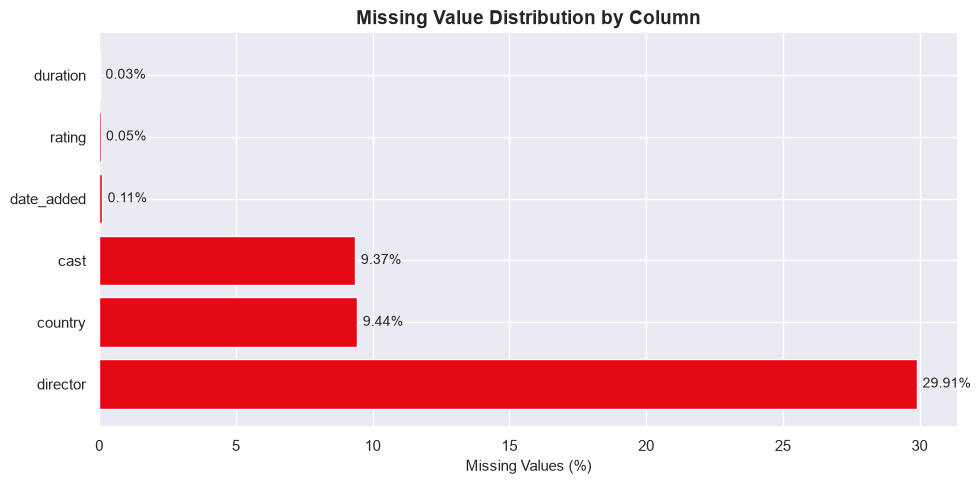

In [ ]:
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)
missing_df    = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)' : missing_pct
}).sort_values('Missing Count', ascending=False)

print('=== MISSING VALUE REPORT ===')
display(missing_df[missing_df['Missing Count'] > 0])

fig, ax = plt.subplots(figsize=(10, 5))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
ax.barh(cols_with_missing.index, cols_with_missing['Missing (%)'],
        color=NETFLIX_RED, edgecolor='white')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Distribution by Column')
for i, v in enumerate(cols_with_missing['Missing (%)']):
    ax.text(v + 0.2, i, f'{v:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### 3.3 Descriptive Statistics

Statistical summary of all columns.

In [5]:
print('=== NUMERICAL COLUMNS ===')
display(df.describe())

print('\n=== CATEGORICAL COLUMNS ===')
cat_cols = df.select_dtypes(include='object').columns
display(df[cat_cols].describe())

=== NUMERICAL COLUMNS ===


,release_year
count,8807.00
mean,2014.18
std,8.82
min,1925.00
25%,2013.00
50%,2017.00
75%,2019.00
max,2021.00



=== CATEGORICAL COLUMNS ===


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned property alarms..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


---
## 4. Data Cleaning and Preprocessing

Based on the observations from Section 3, we address the following issues:

1. **Anomalous ratings**: Some entries have movie durations stored in the `rating` column.
2. **Missing values**: Columns `director`, `cast`, and `country` are filled with `'Unknown'`.
3. **Date parsing**: `date_added` is converted from string to datetime.
4. **Feature engineering**: Extract `year_added`, `month_added`, and numeric `duration_clean`.

In [ ]:
anomalies = df[df['rating'].str.contains('min', na=False)]
print(f'Anomalous rating entries found: {len(anomalies)}')
if not anomalies.empty:
    display(anomalies[['title', 'type', 'rating', 'duration']])
for idx in anomalies.index:
    df.loc[idx, 'duration'] = df.loc[idx, 'rating']
    df.loc[idx, 'rating']   = np.nan

df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

initial_count = len(df)
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)
print(f'Rows removed: {initial_count - len(df)}')
print(f'Remaining  : {len(df):,}')

df['date_added']    = pd.to_datetime(df['date_added'].str.strip())
df['year_added']    = df['date_added'].dt.year
df['month_added']   = df['date_added'].dt.month
df['month_name']    = df['date_added'].dt.strftime('%B')
df['day_of_week']   = df['date_added'].dt.day_name()

df['duration_clean'] = df['duration'].str.extract(r'(\d+)').astype(float)

print('\nCleaning complete. Final shape:', df.shape)

Anomalous rating entries found: 3


,title,type,rating,duration
5541,Louis C.K. 2017,Movie,74 min,NaN
5794,Louis C.K.: Hilarious,Movie,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,NaN


Rows removed: 17
Remaining  : 8,790

Cleaning complete. Final shape: (8790, 17)


### 4.1 Cleaned Dataset Sample

In [7]:
display(df.head(10))

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,day_of_week,duration_clean
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirst...",2021,9,September,Saturday,90.00
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, ...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets o...",2021,9,September,Friday,2.00
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari,...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adve...","To protect his family from a powerful drug lord, skilled...",2021,9,September,Friday,1.00
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the inc...",2021,9,September,Friday,1.00
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaa...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies",In a city of coaching centers known to train India’s fin...,2021,9,September,Friday,2.00
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, Henry Thoma...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brings gloriou...,2021,9,September,Friday,1.00
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, Sofia Cars...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero believes Ear...,2021,9,September,Friday,91.00
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra Duah, Nick ...","United States, Ghana, Burkina Faso, United Kingdom, Germ...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model slips back ...",2021,9,September,Friday,125.00
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Hollywood",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in a 10-week...,2021,9,September,Friday,9.00
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, Timothy Oly...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contends with a f...,2021,9,September,Friday,104.00


---
## 5. Exploratory Data Analysis (EDA)

### 5.1 Content Type Distribution: Movies vs. TV Shows

**Objective:** Understand the proportion of Movies versus TV Shows in Netflix catalog.

=== CONTENT TYPE DISTRIBUTION ===
  Movie     : 6,126 (69.7%)
  TV Show   : 2,664 (30.3%)


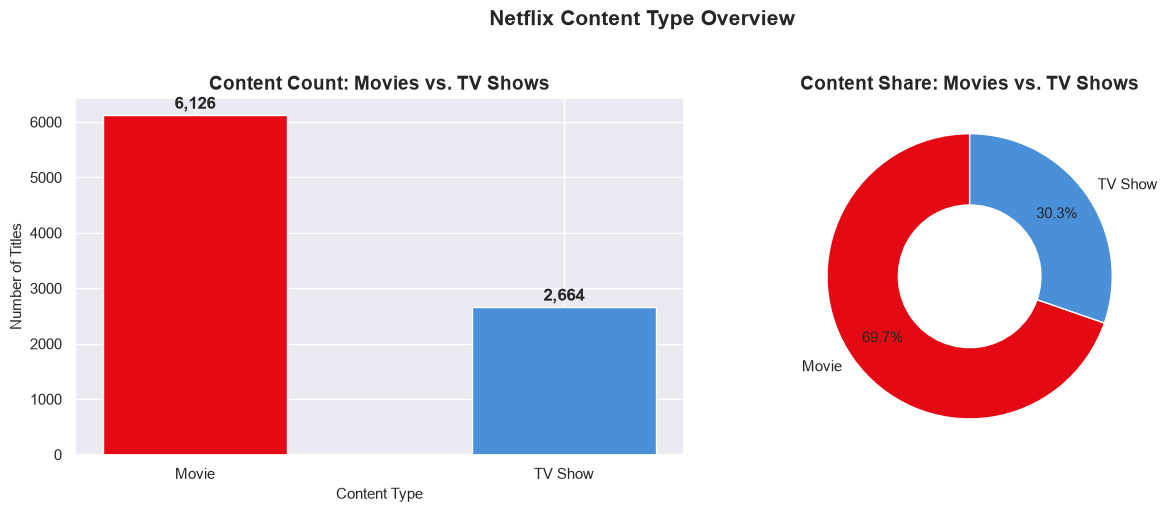


Movies outnumber TV Shows by a ratio of approximately 2.3:1.


In [ ]:
type_counts = df['type'].value_counts()
type_pct    = (type_counts / type_counts.sum() * 100).round(1)

print('=== CONTENT TYPE DISTRIBUTION ===')
for t, c, p in zip(type_counts.index, type_counts.values, type_pct.values):
    print(f'  {t:<10}: {c:,} ({p}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(type_counts.index, type_counts.values,
                   color=[NETFLIX_RED, '#4A90D9'], edgecolor='white', width=0.5)
axes[0].set_title('Content Count: Movies vs. TV Shows')
axes[0].set_ylabel('Number of Titles')
axes[0].set_xlabel('Content Type')
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
        f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold'
    )

wedge_props = dict(width=0.5, edgecolor='white')
axes[1].pie(
    type_counts.values, labels=type_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=[NETFLIX_RED, '#4A90D9'],
    wedgeprops=wedge_props, pctdistance=0.75,
    textprops={'fontsize': 11}
)
axes[1].set_title('Content Share: Movies vs. TV Shows')

plt.suptitle('Netflix Content Type Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ratio = type_counts['Movie'] / type_counts['TV Show']
print(f'\nMovies outnumber TV Shows by a ratio of approximately {ratio:.1f}:1.')

### 5.2 Top Content-Producing Countries

**Objective:** Identify the geographic concentration of Netflix content production.

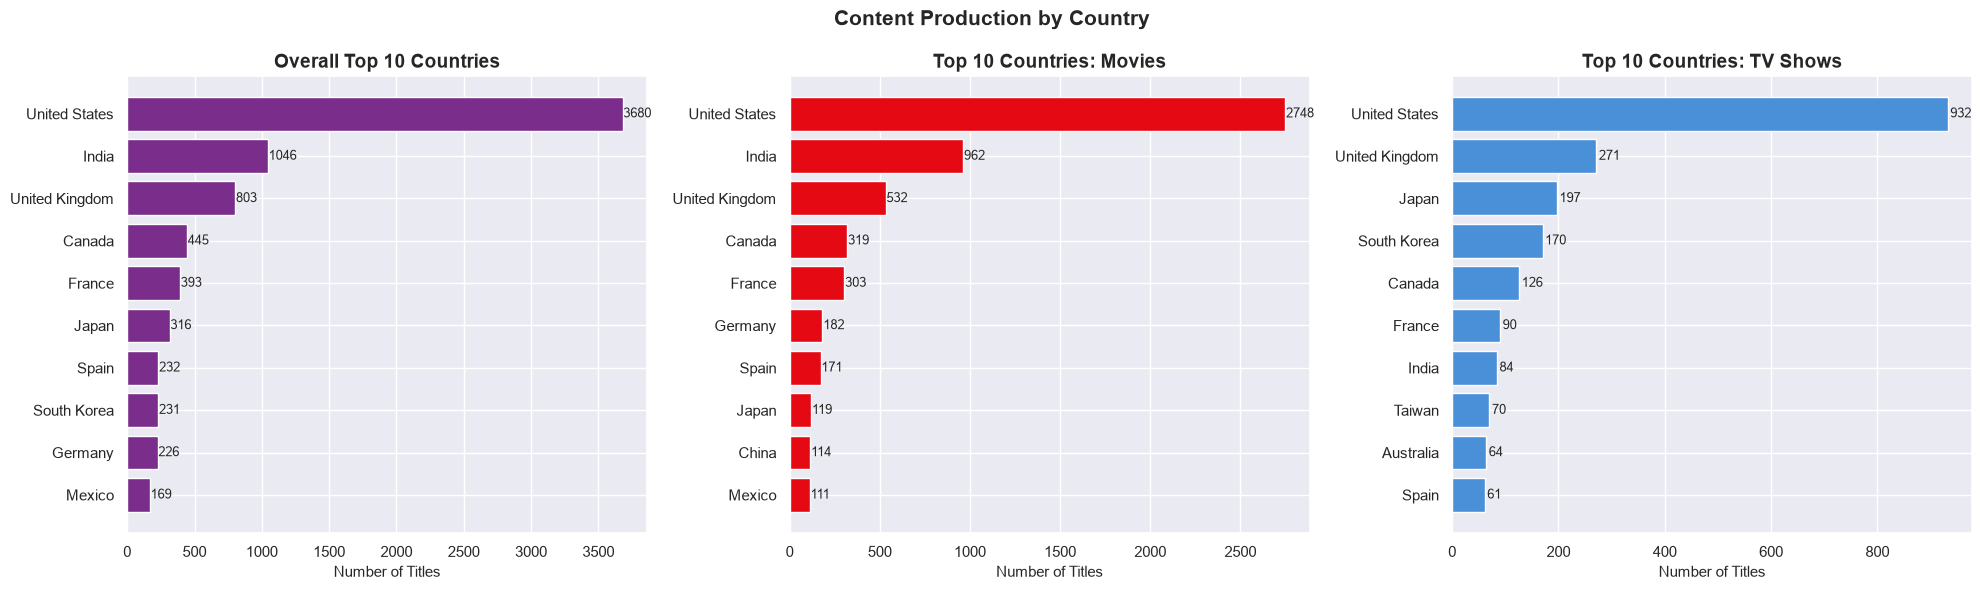


Top 5 Countries (Overall):
  United States       : 3680 titles (34.0%)
  India               : 1046 titles (9.7%)
  United Kingdom      :  803 titles (7.4%)
  Canada              :  445 titles (4.1%)
  France              :  393 titles (3.6%)


In [9]:
country_series = (
    df[df['country'] != 'Unknown']['country']
    .str.split(', ').explode().str.strip()
)
top_countries = country_series.value_counts().head(15)

def top_countries_by_type(dataframe, content_type, n=10):
    mask = (dataframe['type'] == content_type) & (dataframe['country'] != 'Unknown')
    return (
        dataframe[mask]['country']
        .str.split(', ').explode().str.strip()
        .value_counts().head(n)
    )

top_movie_countries  = top_countries_by_type(df, 'Movie')
top_tvshow_countries = top_countries_by_type(df, 'TV Show')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, data, title, color in zip(
    axes,
    [top_countries.head(10), top_movie_countries, top_tvshow_countries],
    ['Overall Top 10 Countries', 'Top 10 Countries: Movies', 'Top 10 Countries: TV Shows'],
    ['#7B2D8B', NETFLIX_RED, '#4A90D9']
):
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Number of Titles')
    for bar in bars:
        ax.text(
            bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9
        )

plt.suptitle('Content Production by Country', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 Countries (Overall):')
for country, count in top_countries.head(5).items():
    pct = count / len(country_series) * 100
    print(f'  {country:<20}: {count:>4} titles ({pct:.1f}%)')

### 5.3 Content Growth Trend Over the Years

**Objective:** Analyze how Netflix library has grown year-over-year.

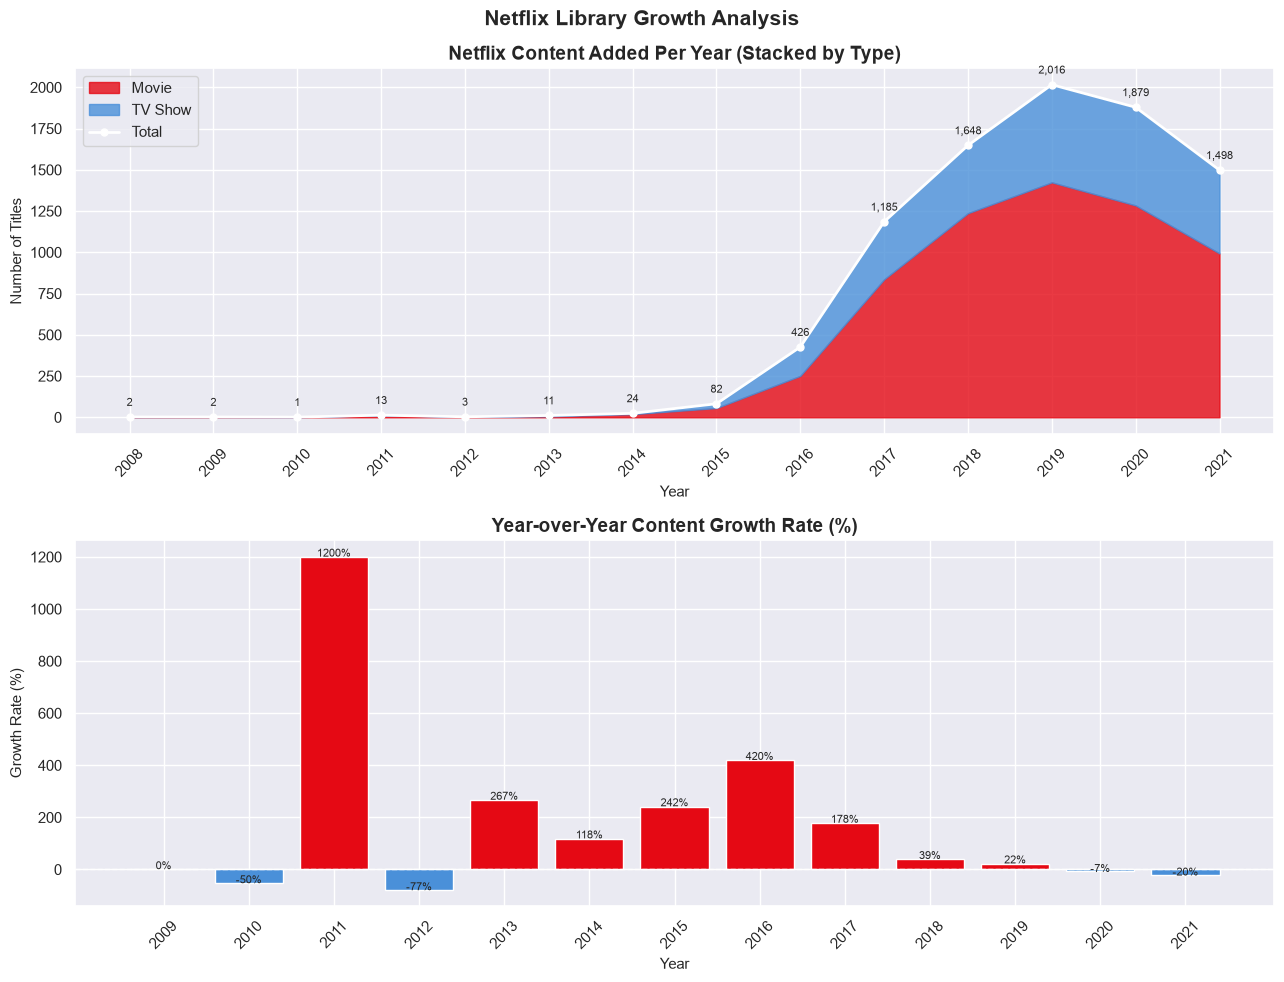


Content Added Per Year:


type,Movie,TV Show,Total,Growth_Rate
year_added,,,,
2008,1,1,2,NaN
2009,2,0,2,0.00
2010,1,0,1,-50.00
2011,13,0,13,1200.00
2012,3,0,3,-76.90
2013,6,5,11,266.70
2014,19,5,24,118.20
2015,56,26,82,241.70
2016,251,175,426,419.50


In [10]:
yearly_type = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly_type['Total']       = yearly_type.sum(axis=1)
yearly_type['Growth_Rate'] = yearly_type['Total'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

ax = axes[0]
if 'Movie' in yearly_type.columns:
    ax.fill_between(yearly_type.index, yearly_type['Movie'],
                    alpha=0.8, color=NETFLIX_RED, label='Movie')
if 'TV Show' in yearly_type.columns:
    ax.fill_between(
        yearly_type.index,
        yearly_type.get('Movie', 0),
        yearly_type.get('Movie', 0) + yearly_type.get('TV Show', 0),
        alpha=0.8, color='#4A90D9', label='TV Show'
    )
ax.plot(yearly_type.index, yearly_type['Total'], 'o-',
        color='white', linewidth=2, markersize=5, label='Total')
ax.set_title('Netflix Content Added Per Year (Stacked by Type)')
ax.set_ylabel('Number of Titles')
ax.set_xlabel('Year')
ax.legend()
ax.set_xticks(yearly_type.index)
ax.tick_params(axis='x', rotation=45)
for x, y in zip(yearly_type.index, yearly_type['Total']):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)

ax2 = axes[1]
growth   = yearly_type['Growth_Rate'].dropna()
colors_g = [NETFLIX_RED if v >= 0 else '#4A90D9' for v in growth.values]
ax2.bar(growth.index, growth.values, color=colors_g, edgecolor='white')
ax2.axhline(0, color='white', linewidth=1, linestyle='--')
ax2.set_title('Year-over-Year Content Growth Rate (%)')
ax2.set_ylabel('Growth Rate (%)')
ax2.set_xlabel('Year')
ax2.set_xticks(growth.index)
ax2.tick_params(axis='x', rotation=45)
for x, y in zip(growth.index, growth.values):
    ax2.text(x, y + (1 if y >= 0 else -3), f'{y:.0f}%', ha='center', fontsize=8)

plt.suptitle('Netflix Library Growth Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nContent Added Per Year:')
display(yearly_type[['Movie', 'TV Show', 'Total', 'Growth_Rate']].round(1))

### 5.4 Seasonal Patterns: Monthly Content Addition

**Objective:** Detect whether Netflix follows a seasonal strategy in releasing new content.

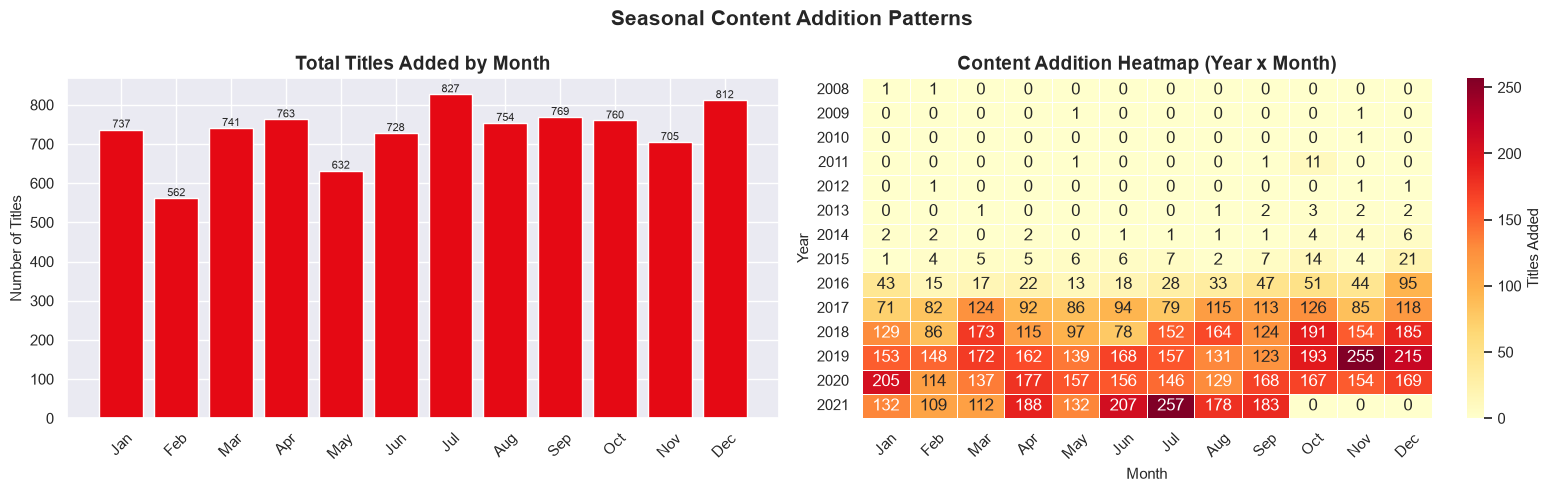

Peak month: July (827 titles)


In [11]:
MONTH_ORDER = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_type  = df.groupby(['month_name', 'type']).size().unstack(fill_value=0)
monthly_type  = monthly_type.reindex(MONTH_ORDER)
monthly_total = monthly_type.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
bars = ax1.bar(range(12), monthly_total.values, color=NETFLIX_RED, edgecolor='white')
ax1.set_xticks(range(12))
ax1.set_xticklabels([m[:3] for m in MONTH_ORDER], rotation=45)
ax1.set_title('Total Titles Added by Month')
ax1.set_ylabel('Number of Titles')
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
        str(int(bar.get_height())), ha='center', fontsize=8
    )

ax2 = axes[1]
pivot_heatmap = df.groupby(['year_added', 'month_name']).size().unstack(fill_value=0)
pivot_heatmap = pivot_heatmap.reindex(columns=MONTH_ORDER)
sns.heatmap(
    pivot_heatmap, cmap='YlOrRd', annot=True, fmt='d',
    linewidths=0.5, ax=ax2, cbar_kws={'label': 'Titles Added'}
)
ax2.set_title('Content Addition Heatmap (Year x Month)')
ax2.set_xlabel('Month')
ax2.set_ylabel('Year')
ax2.set_xticklabels([m[:3] for m in MONTH_ORDER], rotation=45)

plt.suptitle('Seasonal Content Addition Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

peak_month = monthly_total.idxmax()
print(f'Peak month: {peak_month} ({int(monthly_total[peak_month]):,} titles)')

### 5.5 Age Rating Distribution

**Objective:** Understand Netflix audience segmentation through content age ratings.

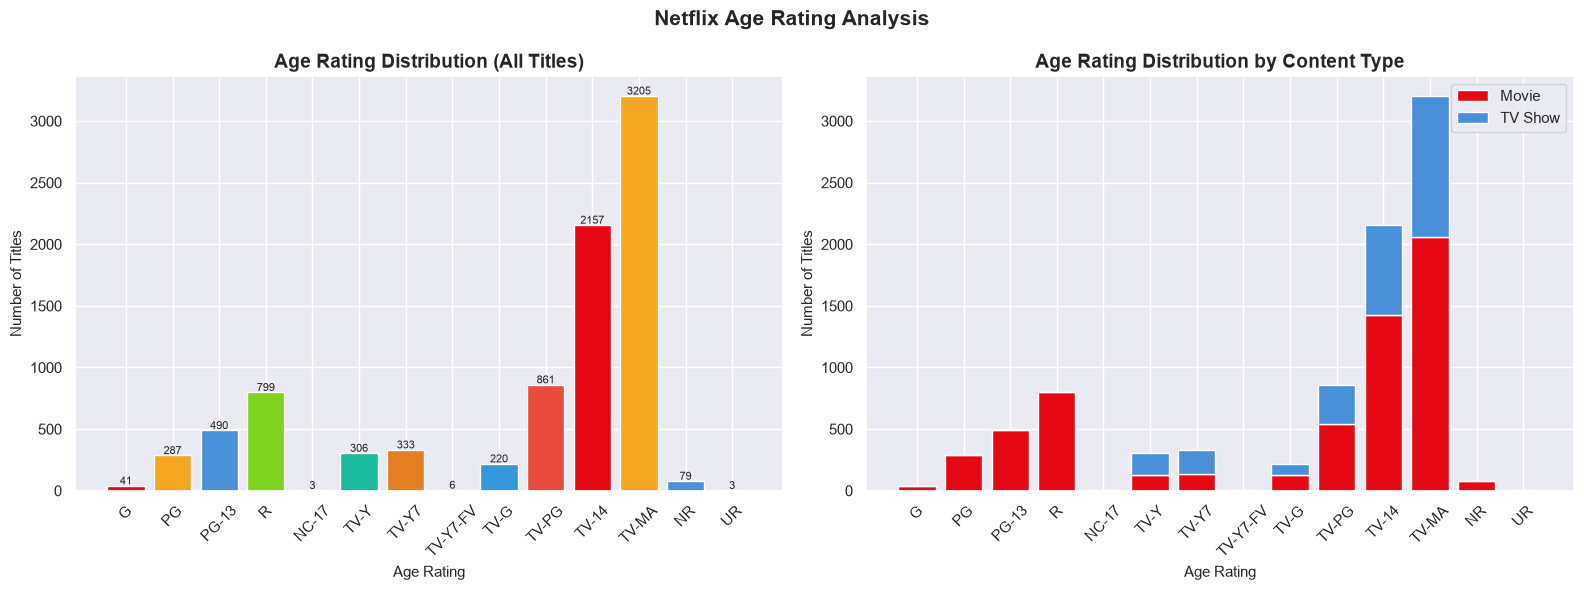

Most common rating: TV-MA (3,205 titles, 36.5%)


In [12]:
rating_order = [
    'G', 'PG', 'PG-13', 'R', 'NC-17',
    'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G', 'TV-PG', 'TV-14', 'TV-MA',
    'NR', 'UR'
]

rating_counts  = df['rating'].value_counts()
rating_counts  = rating_counts.reindex([r for r in rating_order if r in rating_counts.index])
rating_by_type = df.groupby(['rating', 'type']).size().unstack(fill_value=0)
rating_by_type = rating_by_type.reindex([r for r in rating_order if r in rating_by_type.index])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
bars = ax1.bar(rating_counts.index, rating_counts.values,
               color=COLOR_PALETTE[:len(rating_counts)], edgecolor='white')
ax1.set_title('Age Rating Distribution (All Titles)')
ax1.set_xlabel('Age Rating')
ax1.set_ylabel('Number of Titles')
ax1.tick_params(axis='x', rotation=45)
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
        str(int(bar.get_height())), ha='center', fontsize=8
    )

ax2 = axes[1]
bottom = np.zeros(len(rating_by_type))
for col, color in zip(rating_by_type.columns, [NETFLIX_RED, '#4A90D9']):
    ax2.bar(rating_by_type.index, rating_by_type[col], bottom=bottom,
            label=col, color=color, edgecolor='white')
    bottom += rating_by_type[col].values
ax2.set_title('Age Rating Distribution by Content Type')
ax2.set_xlabel('Age Rating')
ax2.set_ylabel('Number of Titles')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.suptitle('Netflix Age Rating Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

top_rating = rating_counts.idxmax()
top_pct    = rating_counts.max() / rating_counts.sum() * 100
print(f'Most common rating: {top_rating} ({int(rating_counts.max()):,} titles, {top_pct:.1f}%)')

### 5.6 Genre Analysis

**Objective:** Identify the most popular content categories on Netflix.

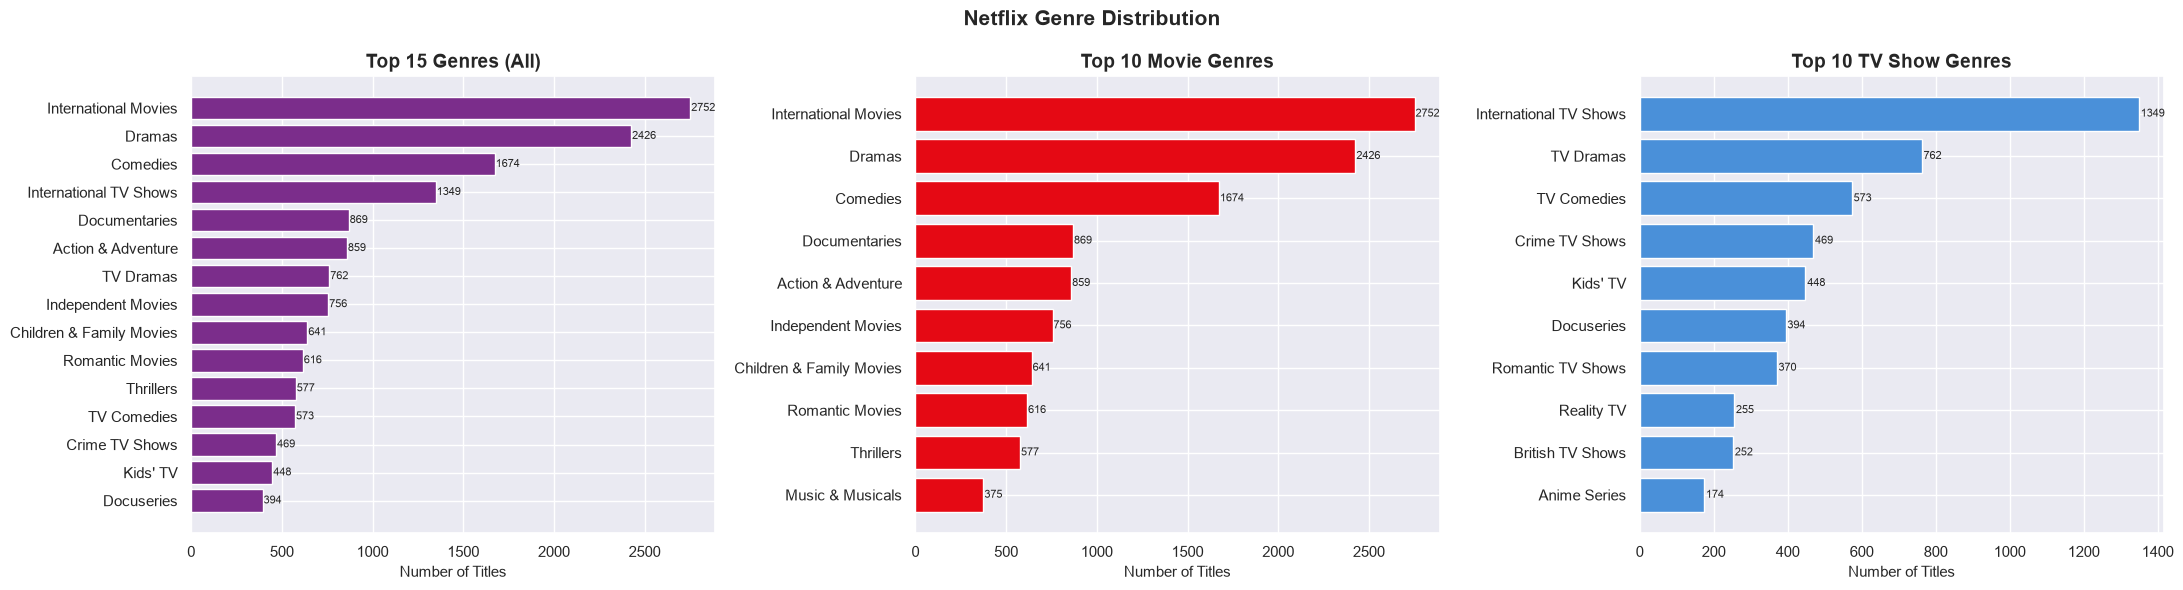

Top 10 Genres Overall:
  International Movies               : 2752
  Dramas                             : 2426
  Comedies                           : 1674
  International TV Shows             : 1349
  Documentaries                      :  869
  Action & Adventure                 :  859
  TV Dramas                          :  762
  Independent Movies                 :  756
  Children & Family Movies           :  641
  Romantic Movies                    :  616


In [13]:
all_genres   = df['listed_in'].str.split(', ').explode().str.strip()
genre_counts = all_genres.value_counts()

genre_movie = (
    df[df['type'] == 'Movie']['listed_in']
    .str.split(', ').explode().str.strip()
    .value_counts().head(10)
)
genre_tv = (
    df[df['type'] == 'TV Show']['listed_in']
    .str.split(', ').explode().str.strip()
    .value_counts().head(10)
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, data, title, color in zip(
    axes,
    [genre_counts.head(15), genre_movie, genre_tv],
    ['Top 15 Genres (All)', 'Top 10 Movie Genres', 'Top 10 TV Show Genres'],
    ['#7B2D8B', NETFLIX_RED, '#4A90D9']
):
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Number of Titles')
    for bar in bars:
        ax.text(
            bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=8
        )

plt.suptitle('Netflix Genre Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 Genres Overall:')
for genre, count in genre_counts.head(10).items():
    print(f'  {genre:<35}: {count:>4}')

### 5.7 Movie Duration Analysis

**Objective:** Examine the distribution of movie lengths and identify typical runtime ranges.

=== MOVIE DURATION STATISTICS (minutes) ===
count   6126.00
mean      99.58
std       28.28
min        3.00
25%       87.00
50%       98.00
75%      114.00
max      312.00


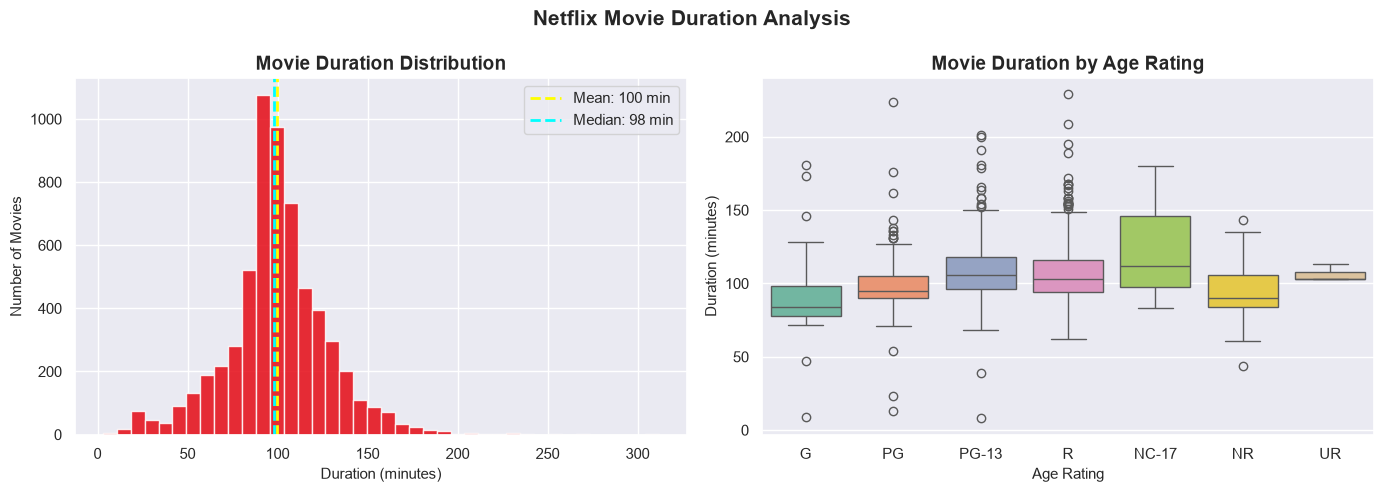


Duration Bucket Distribution:
  < 60 min       :  486 movies (7.9%)
  60-90 min      : 1503 movies (24.5%)
  90-120 min     : 2995 movies (48.9%)
  120-150 min    :  897 movies (14.6%)
  > 150 min      :  244 movies (4.0%)


In [14]:
movies       = df[df['type'] == 'Movie'].copy()
movies_clean = movies.dropna(subset=['duration_clean']).copy()

print('=== MOVIE DURATION STATISTICS (minutes) ===')
print(movies_clean['duration_clean'].describe().to_string())

mean_dur   = movies_clean['duration_clean'].mean()
median_dur = movies_clean['duration_clean'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(movies_clean['duration_clean'], bins=40, color=NETFLIX_RED,
         edgecolor='white', alpha=0.85)
ax1.axvline(mean_dur,   color='yellow', linestyle='--', linewidth=2,
            label=f'Mean: {mean_dur:.0f} min')
ax1.axvline(median_dur, color='cyan',   linestyle='--', linewidth=2,
            label=f'Median: {median_dur:.0f} min')
ax1.set_title('Movie Duration Distribution')
ax1.set_xlabel('Duration (minutes)')
ax1.set_ylabel('Number of Movies')
ax1.legend()

ax2 = axes[1]
movie_rating_order = [r for r in ['G', 'PG', 'PG-13', 'R', 'NC-17', 'NR', 'UR']
                      if r in movies_clean['rating'].unique()]
movies_filtered = movies_clean[movies_clean['rating'].isin(movie_rating_order)]
if not movies_filtered.empty:
    sns.boxplot(data=movies_filtered, x='rating', y='duration_clean',
                order=movie_rating_order, palette='Set2', ax=ax2)
    ax2.set_title('Movie Duration by Age Rating')
    ax2.set_xlabel('Age Rating')
    ax2.set_ylabel('Duration (minutes)')

plt.suptitle('Netflix Movie Duration Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

bins   = [0, 60, 90, 120, 150, 300]
labels = ['< 60 min', '60-90 min', '90-120 min', '120-150 min', '> 150 min']
movies_clean['duration_bucket'] = pd.cut(movies_clean['duration_clean'], bins=bins, labels=labels)
bucket_counts = movies_clean['duration_bucket'].value_counts().reindex(labels)
print('\nDuration Bucket Distribution:')
for bucket, count in bucket_counts.items():
    pct = count / len(movies_clean) * 100
    print(f'  {bucket:<15}: {int(count):>4} movies ({pct:.1f}%)')

### 5.8 TV Show Season Analysis

**Objective:** Understand the distribution of season counts for TV Shows.

=== TV SHOW SEASON STATISTICS ===
count   2664.00
mean       1.75
std        1.55
min        1.00
25%        1.00
50%        1.00
75%        2.00
max       17.00


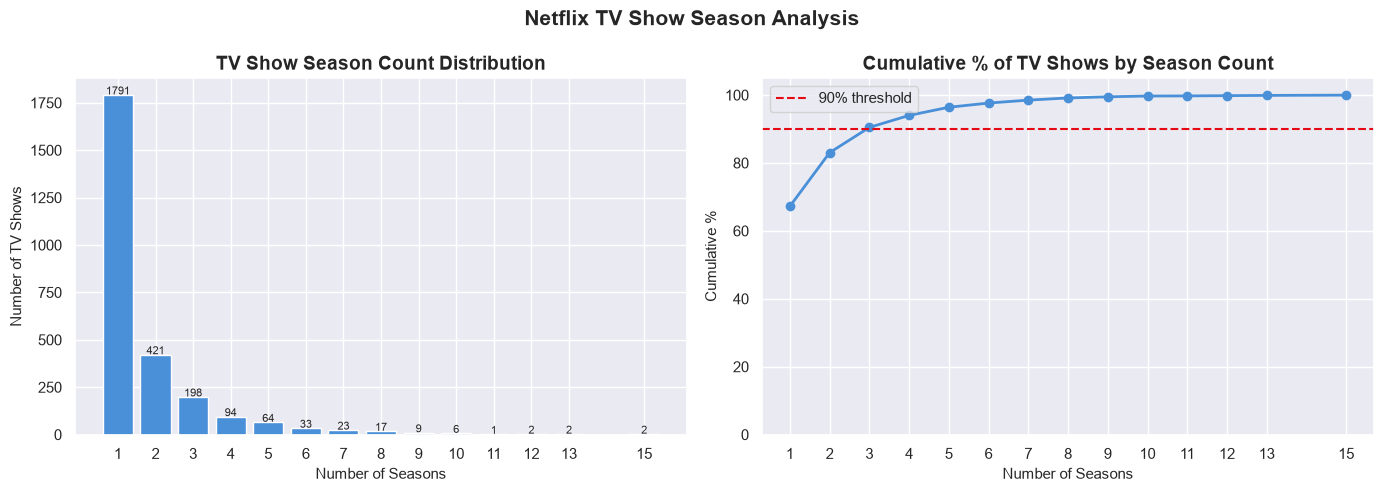


TV Shows with only 1 season: 1,791 (67.2%)


In [15]:
tv_shows      = df[df['type'] == 'TV Show'].copy()
tv_clean      = tv_shows.dropna(subset=['duration_clean'])
season_counts = tv_clean['duration_clean'].value_counts().sort_index()

print('=== TV SHOW SEASON STATISTICS ===')
print(tv_clean['duration_clean'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1     = axes[0]
plot_data = season_counts[season_counts.index <= 15]
ax1.bar(plot_data.index.astype(int), plot_data.values,
        color='#4A90D9', edgecolor='white')
ax1.set_title('TV Show Season Count Distribution')
ax1.set_xlabel('Number of Seasons')
ax1.set_ylabel('Number of TV Shows')
ax1.set_xticks(plot_data.index.astype(int))
for x, y in zip(plot_data.index.astype(int), plot_data.values):
    ax1.text(x, y + 3, str(int(y)), ha='center', fontsize=8)

ax2        = axes[1]
cumulative = season_counts.cumsum() / season_counts.sum() * 100
cum_plot   = cumulative[cumulative.index <= 15]
ax2.plot(cum_plot.index.astype(int), cum_plot.values,
         marker='o', color='#4A90D9', linewidth=2)
ax2.axhline(90, color=NETFLIX_RED, linestyle='--', label='90% threshold')
ax2.set_title('Cumulative % of TV Shows by Season Count')
ax2.set_xlabel('Number of Seasons')
ax2.set_ylabel('Cumulative %')
ax2.set_xticks(cum_plot.index.astype(int))
ax2.set_ylim(0, 105)
ax2.legend()

plt.suptitle('Netflix TV Show Season Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

single_pct = season_counts.get(1.0, 0) / len(tv_clean) * 100
print(f'\nTV Shows with only 1 season: {int(season_counts.get(1.0, 0)):,} ({single_pct:.1f}%)')

### 5.9 Most Prolific Directors

**Objective:** Identify the directors who have contributed the most titles to Netflix catalog.

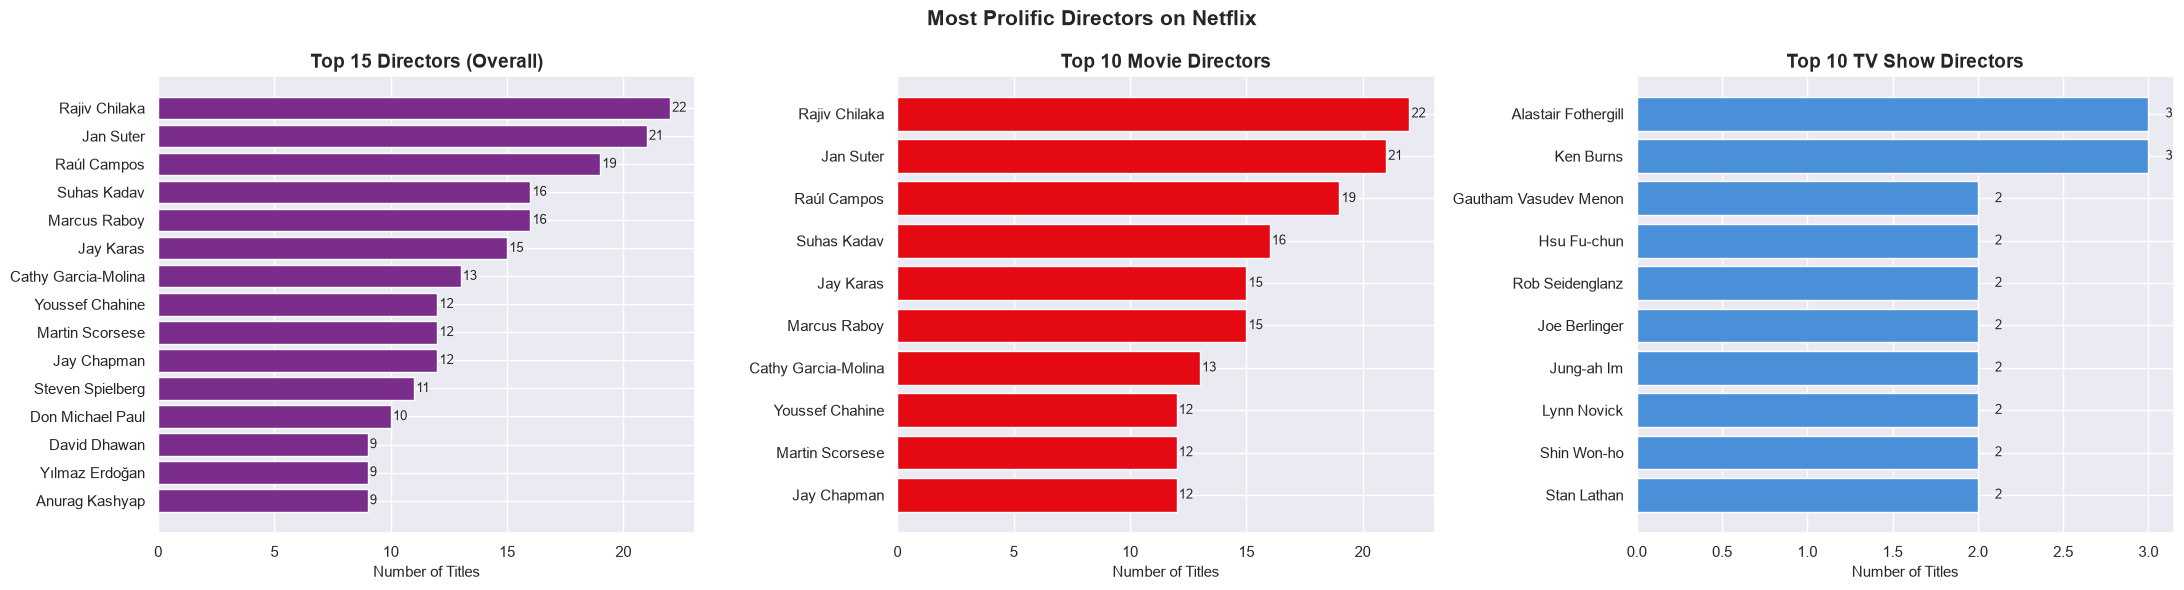

In [16]:
dirs_all = (
    df[df['director'] != 'Unknown']['director']
    .str.split(', ').explode().str.strip()
)
top_directors  = dirs_all.value_counts().head(15)

top_dir_movies = (
    df[(df['director'] != 'Unknown') & (df['type'] == 'Movie')]['director']
    .str.split(', ').explode().str.strip().value_counts().head(10)
)
top_dir_tv = (
    df[(df['director'] != 'Unknown') & (df['type'] == 'TV Show')]['director']
    .str.split(', ').explode().str.strip().value_counts().head(10)
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, data, title, color in zip(
    axes,
    [top_directors, top_dir_movies, top_dir_tv],
    ['Top 15 Directors (Overall)', 'Top 10 Movie Directors', 'Top 10 TV Show Directors'],
    ['#7B2D8B', NETFLIX_RED, '#4A90D9']
):
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Number of Titles')
    for bar in bars:
        ax.text(
            bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9
        )

plt.suptitle('Most Prolific Directors on Netflix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.10 Most Frequently Appearing Cast Members

**Objective:** Identify the most active actors and actresses across Netflix catalog.

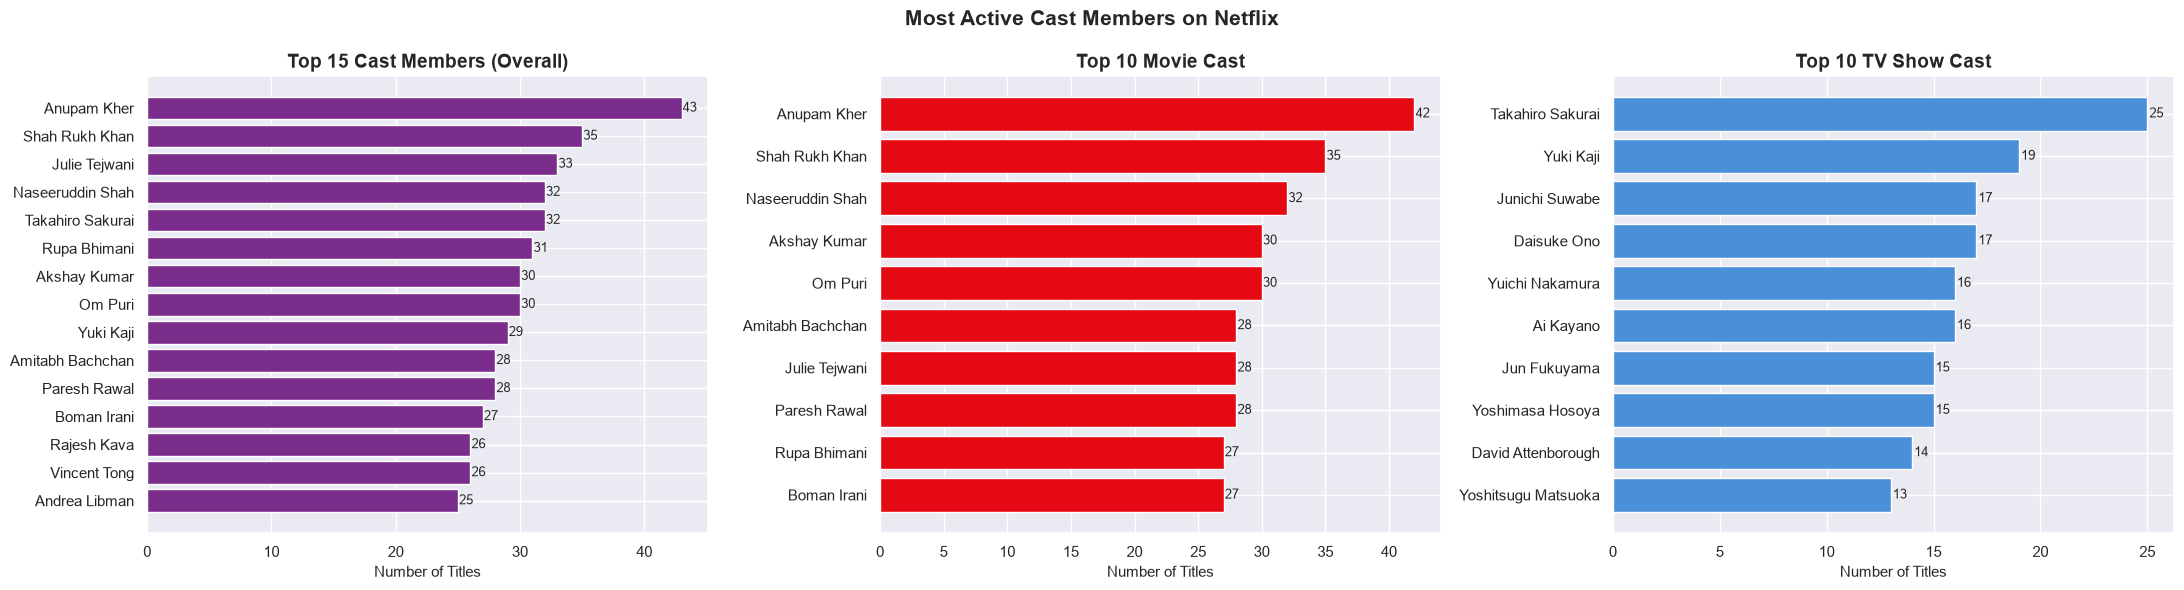

In [17]:
cast_all = (
    df[df['cast'] != 'Unknown']['cast']
    .str.split(', ').explode().str.strip()
)
top_cast = cast_all.value_counts().head(15)

top_cast_movies = (
    df[(df['cast'] != 'Unknown') & (df['type'] == 'Movie')]['cast']
    .str.split(', ').explode().str.strip().value_counts().head(10)
)
top_cast_tv = (
    df[(df['cast'] != 'Unknown') & (df['type'] == 'TV Show')]['cast']
    .str.split(', ').explode().str.strip().value_counts().head(10)
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, data, title, color in zip(
    axes,
    [top_cast, top_cast_movies, top_cast_tv],
    ['Top 15 Cast Members (Overall)', 'Top 10 Movie Cast', 'Top 10 TV Show Cast'],
    ['#7B2D8B', NETFLIX_RED, '#4A90D9']
):
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Number of Titles')
    for bar in bars:
        ax.text(
            bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9
        )

plt.suptitle('Most Active Cast Members on Netflix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.11 Release Year vs. Year Added (Release Lag Analysis)

**Objective:** Measure how quickly content is added to Netflix after its original release.

=== LAG BETWEEN RELEASE AND NETFLIX ADDITION ===
          count  mean  std  min  25%  50%  75%   max
type                                                
Movie   6020.00  4.93 7.53 0.00 0.00 1.00 6.00 40.00
TV Show 2644.00  2.14 4.21 0.00 0.00 0.00 2.00 38.00


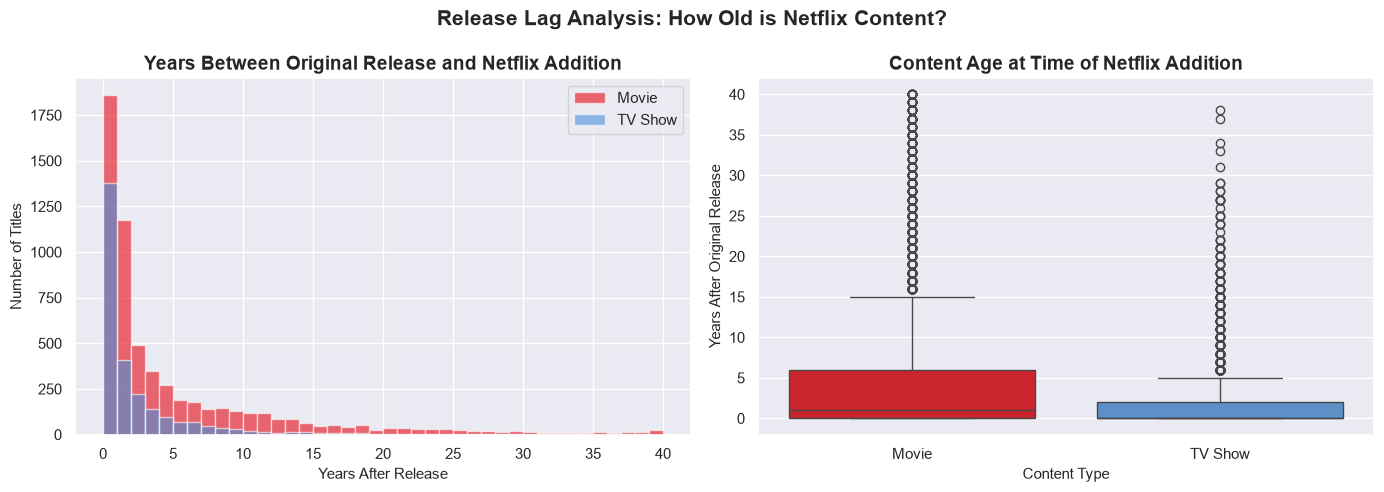


Titles added same year as release: 3,239 (37.4%)


In [18]:
df['lag_years'] = df['year_added'] - df['release_year']
lag_clean = df[(df['lag_years'] >= 0) & (df['lag_years'] <= 40)].copy()

print('=== LAG BETWEEN RELEASE AND NETFLIX ADDITION ===')
print(lag_clean.groupby('type')['lag_years'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for content_type, color in [('Movie', NETFLIX_RED), ('TV Show', '#4A90D9')]:
    subset = lag_clean[lag_clean['type'] == content_type]['lag_years']
    ax1.hist(subset, bins=range(0, 41), alpha=0.6, label=content_type, color=color)
ax1.set_title('Years Between Original Release and Netflix Addition')
ax1.set_xlabel('Years After Release')
ax1.set_ylabel('Number of Titles')
ax1.legend()

ax2 = axes[1]
sns.boxplot(data=lag_clean, x='type', y='lag_years',
            palette=[NETFLIX_RED, '#4A90D9'], ax=ax2)
ax2.set_title('Content Age at Time of Netflix Addition')
ax2.set_xlabel('Content Type')
ax2.set_ylabel('Years After Original Release')

plt.suptitle('Release Lag Analysis: How Old is Netflix Content?',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

same_year = lag_clean[lag_clean['lag_years'] == 0]
print(f'\nTitles added same year as release: '
      f'{len(same_year):,} ({len(same_year)/len(lag_clean)*100:.1f}%)')

### 5.12 Genre Trend Over Time

**Objective:** Identify which genres have grown or declined in Netflix content strategy over the years.

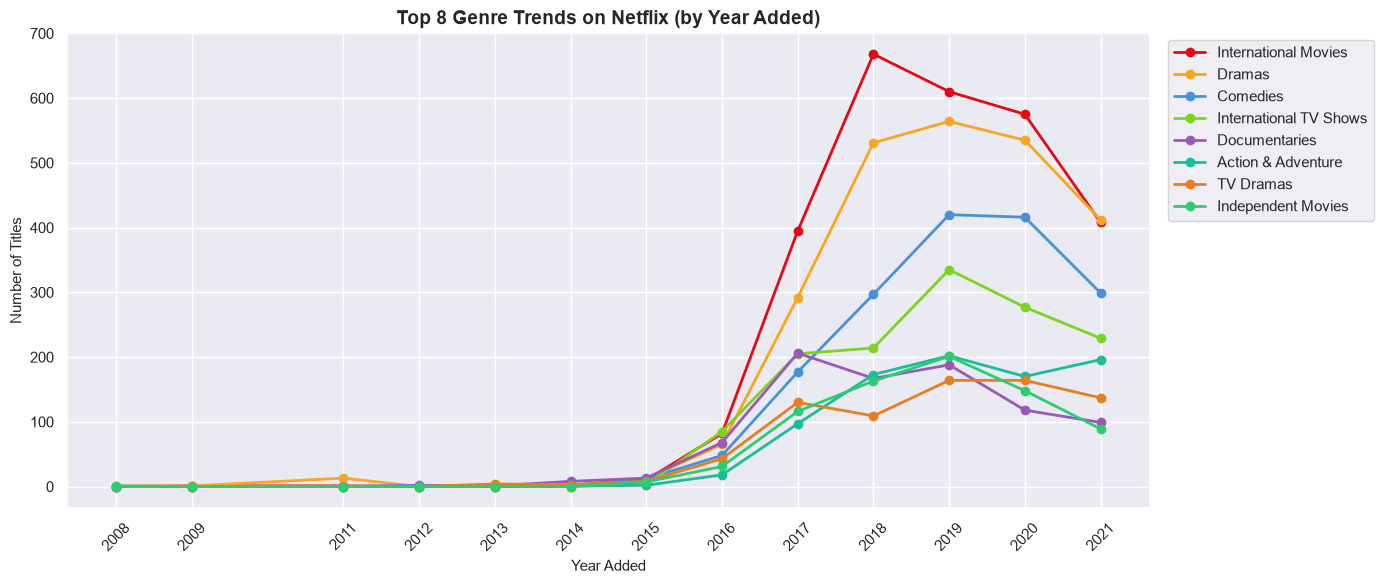

In [19]:
top8_genres = all_genres.value_counts().head(8).index.tolist()

genre_year_rows = []
for _, row in df.iterrows():
    for genre in str(row['listed_in']).split(', '):
        genre = genre.strip()
        if genre in top8_genres:
            genre_year_rows.append({'genre': genre, 'year_added': row['year_added']})

genre_year_df    = pd.DataFrame(genre_year_rows)
genre_year_pivot = (
    genre_year_df
    .groupby(['year_added', 'genre'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
for i, genre in enumerate(top8_genres):
    if genre in genre_year_pivot.columns:
        ax.plot(
            genre_year_pivot.index, genre_year_pivot[genre],
            marker='o', label=genre, color=COLOR_PALETTE[i], linewidth=2
        )

ax.set_title('Top 8 Genre Trends on Netflix (by Year Added)')
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticks(genre_year_pivot.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Key Findings Summary

In [20]:
total_titles     = len(df)
n_movies         = int((df['type'] == 'Movie').sum())
n_tv             = int((df['type'] == 'TV Show').sum())
unique_countries = int(country_series.nunique())
unique_genres_n  = int(all_genres.nunique())
yr_min           = int(df['year_added'].min())
yr_max           = int(df['year_added'].max())
avg_movie_dur    = float(movies_clean['duration_clean'].mean())
avg_tv_seasons   = float(tv_clean['duration_clean'].mean())
pct_single_sea   = float(season_counts.get(1.0, 0) / len(tv_clean) * 100)
top_country_nm   = top_countries.idxmax()
top_genre_nm     = genre_counts.idxmax()
top_rating_nm    = rating_counts.idxmax()

summary = pd.DataFrame({
    'Metric': [
        'Total Titles in Dataset',
        'Number of Movies',
        'Number of TV Shows',
        'Unique Content-Producing Countries',
        'Unique Genres / Categories',
        'Content Added (Year Range)',
        'Average Movie Duration',
        'Average TV Show Seasons',
        'TV Shows with Only 1 Season',
        'Top Producing Country',
        'Most Popular Genre',
        'Most Common Age Rating',
    ],
    'Value': [
        f'{total_titles:,}',
        f'{n_movies:,}  ({n_movies/total_titles*100:.1f}%)',
        f'{n_tv:,}  ({n_tv/total_titles*100:.1f}%)',
        str(unique_countries),
        str(unique_genres_n),
        f'{yr_min} - {yr_max}',
        f'{avg_movie_dur:.0f} minutes',
        f'{avg_tv_seasons:.1f} seasons',
        f'{pct_single_sea:.1f}%',
        top_country_nm,
        top_genre_nm,
        top_rating_nm,
    ]
})

print('=== KEY FINDINGS SUMMARY ===')
display(summary.set_index('Metric'))

=== KEY FINDINGS SUMMARY ===


,Value
Metric,
Total Titles in Dataset,"8,790"
Number of Movies,"6,126 (69.7%)"
Number of TV Shows,"2,664 (30.3%)"
Unique Content-Producing Countries,127
Unique Genres / Categories,42
Content Added (Year Range),2008 - 2021
Average Movie Duration,100 minutes
Average TV Show Seasons,1.8 seasons
TV Shows with Only 1 Season,67.2%


---
## 7. Conclusions and Business Implications

### Content Strategy
- **Movie-centric catalog**: Netflix library is predominantly Movies. However, TV Shows tend to drive sustained engagement through multi-season narratives.
- **US dominance with global diversification**: The United States remains the largest content producer, but significant growth from India and the UK reflects an increasingly global strategy.
- **Rapid library expansion**: The 2016-2019 period saw the most dramatic growth in Netflix library, coinciding with its global expansion phase.

### Audience Targeting
- **Mature content focus**: The prevalence of TV-MA and R-rated content reflects Netflix primary target demographic of adults, distinguishing it from family-oriented streaming competitors.
- **Genre breadth**: International Movies, Dramas, and Comedies dominate, suggesting Netflix aims to appeal to broad, global tastes.

### Content Characteristics
- **Movie runtimes**: Most Netflix movies fall within the 90-120 minute range, consistent with theatrical norms.
- **Short-season preference**: The majority of Netflix TV Shows have only one season, reflecting both original content commissioning patterns and licensing of limited series.
- **Timely acquisition**: A significant portion of content is added to Netflix within the same year as its original release, indicating a competitive licensing strategy.

---
*End of Analysis*